# SGD for Policy Optimisation

## Key insight

REINFORCE **is** vanilla SGD applied to the policy gradient objective.
Each episode produces one noisy gradient estimate; the update is:

```
theta_{t+1} = theta_t + lr * g_t
```

where `g_t = G_t * grad_theta log pi(a_t|s_t)` is the REINFORCE gradient.

For tabular softmax with cost minimisation the gradient at state s_t is:

```
g[s_t, a]  = G_t * (pi(a|s_t) - I[a = a_t])   # = G_t * (pi - I_a)
```

This notebook compares three first-order optimisers applied to this gradient:

| Optimiser | Update |
|-----------|--------|
| **Vanilla SGD** | `theta += lr * g` |
| **SGD + Momentum** | `v = beta*v + g; theta += lr * v` |
| **SGD + Nesterov** | lookahead momentum correction |

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from environment.gridworld import GridWorldEnv
from experiments.run_all import load_config
from utils.plotting import (
    plot_multi_curves, plot_vstar_heatmap,
    plot_policy_arrows, plot_summary_bar, save_figure,
)
from utils.metrics import signed_error, abs_error, policy_eval_error

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

cfg    = load_config()
N_EPS  = cfg['environment']['n_episodes']
MAX_ST = cfg['environment']['max_steps_per_episode']
GAMMA  = cfg['environment']['gamma']
LR     = cfg['reinforce']['lr_policy']

def flat(obs):
    return int(obs[0]) * 8 + int(obs[1])

## 1. SGD Policy Agent

In [2]:
def _softmax(t: np.ndarray) -> np.ndarray:
    e = np.exp(t - t.max())
    return e / e.sum()


class SGDPolicyAgent:
    """
    Episodic REINFORCE gradient with a configurable first-order optimiser.

    The gradient estimate for one episode is:
        g[s, :] = sum_{t: s_t=s} G_t * (pi(.|s) - I_{a_t})

    Three modes:
        momentum=0              -> vanilla SGD (identical to REINFORCE)
        momentum>0, nesterov=False -> heavy-ball momentum
        momentum>0, nesterov=True  -> Nesterov accelerated gradient

    The velocity tensor persists across episodes.
    """

    def __init__(self, rng, gamma: float, lr: float,
                 momentum: float = 0.0, nesterov: bool = False,
                 n_states: int = 64, n_actions: int = 9):
        self._rng = rng
        self.gamma = gamma
        self.lr = lr
        self.momentum = momentum
        self.nesterov = nesterov
        self.n_states = n_states
        self.n_actions = n_actions
        self.theta = np.zeros((n_states, n_actions))
        self._vel  = np.zeros((n_states, n_actions))   # momentum buffer
        self._buf  = []

    def select_action(self, s: int) -> int:
        return int(self._rng.choice(self.n_actions, p=_softmax(self.theta[s, :])))

    def reset_episode(self):
        self._buf = []

    def update(self, s: int, a: int, cost: float, s_prime: int, done: bool):
        self._buf.append((s, a, float(cost)))

    def finish_episode(self):
        # accumulate per-state gradient vectors
        grads: dict[int, np.ndarray] = {}
        G = 0.0
        for s, a, cost in reversed(self._buf):
            G = cost + self.gamma * G
            pi = _softmax(self.theta[s, :])
            g  = pi.copy()
            g[a] -= 1.0               # cost-min: (pi - I_a)
            if s not in grads:
                grads[s] = np.zeros(self.n_actions)
            grads[s] += G * g

        for s, g_s in grads.items():
            if self.momentum > 0:
                if self.nesterov:
                    v_prev = self._vel[s, :].copy()
                    self._vel[s, :] = self.momentum * self._vel[s, :] + g_s
                    # Nesterov: theta += lr * (beta*v_new + g) - lr * beta*v_prev
                    self.theta[s, :] += self.lr * (self.momentum * self._vel[s, :] + g_s - v_prev)
                else:
                    self._vel[s, :] = self.momentum * self._vel[s, :] + g_s
                    self.theta[s, :] += self.lr * self._vel[s, :]
            else:
                self.theta[s, :] += self.lr * g_s

    def get_policy(self) -> np.ndarray:
        return np.vstack([_softmax(self.theta[s, :]) for s in range(self.n_states)])

    def get_value_estimate(self) -> np.ndarray:
        return np.zeros(self.n_states)   # no critic in pure PG

## 2. Training Loop

In [3]:
def run_one_episode(agent, env, max_steps: int):
    agent.reset_episode()
    obs = env.reset()
    s = flat(obs)
    for _ in range(max_steps):
        a = agent.select_action(s)
        obs, cost, done, _ = env.step(a)
        s_prime = flat(obs)
        agent.update(s, a, cost, s_prime, done)
        s = s_prime
        if done:
            break
    agent.finish_episode()


def multi_run(factory, n_runs=3, n_eps=N_EPS, max_steps=MAX_ST,
              eval_every=50, base_seed=0) -> dict:
    """Run factory() for n_runs seeds; returns a results dict for plotting utils."""
    ckpt_eps   = np.arange(eval_every - 1, n_eps, eval_every)
    signed_arr = np.zeros((n_runs, n_eps))
    abs_arr    = np.zeros((n_runs, n_eps))
    policy_arr = np.zeros((n_runs, len(ckpt_eps)))

    for run in range(n_runs):
        rng_a = np.random.default_rng(base_seed + run * 1000)
        rng_e = np.random.default_rng(base_seed + run * 1000 + 1)
        agent = factory(rng_a)
        env   = GridWorldEnv(rng_e)
        ci = 0
        for ep in range(n_eps):
            run_one_episode(agent, env, max_steps)
            V = agent.get_value_estimate()
            signed_arr[run, ep] = signed_error(V)
            abs_arr[run, ep]    = abs_error(V)
            if ci < len(ckpt_eps) and ep == ckpt_eps[ci]:
                policy_arr[run, ci] = policy_eval_error(agent.get_policy())
                ci += 1
        while ci < len(ckpt_eps):
            policy_arr[run, ci] = policy_eval_error(agent.get_policy())
            ci += 1

    return {'signed_err': signed_arr, 'abs_err': abs_arr,
            'policy_err': policy_arr, 'checkpoint_eps': ckpt_eps,
            'n_runs': n_runs, 'n_episodes': n_eps}

## 3. Optimiser Comparison

In [4]:
N_RUNS = 3

print('Vanilla SGD ...')
sgd_results = multi_run(
    lambda rng: SGDPolicyAgent(rng, GAMMA, LR, momentum=0.0), N_RUNS)

print('SGD + Momentum (beta=0.9) ...')
mom_results = multi_run(
    lambda rng: SGDPolicyAgent(rng, GAMMA, LR, momentum=0.9), N_RUNS)

print('SGD + Nesterov (beta=0.9) ...')
nest_results = multi_run(
    lambda rng: SGDPolicyAgent(rng, GAMMA, LR, momentum=0.9, nesterov=True), N_RUNS)

Vanilla SGD ...
SGD + Momentum (beta=0.9) ...
SGD + Nesterov (beta=0.9) ...


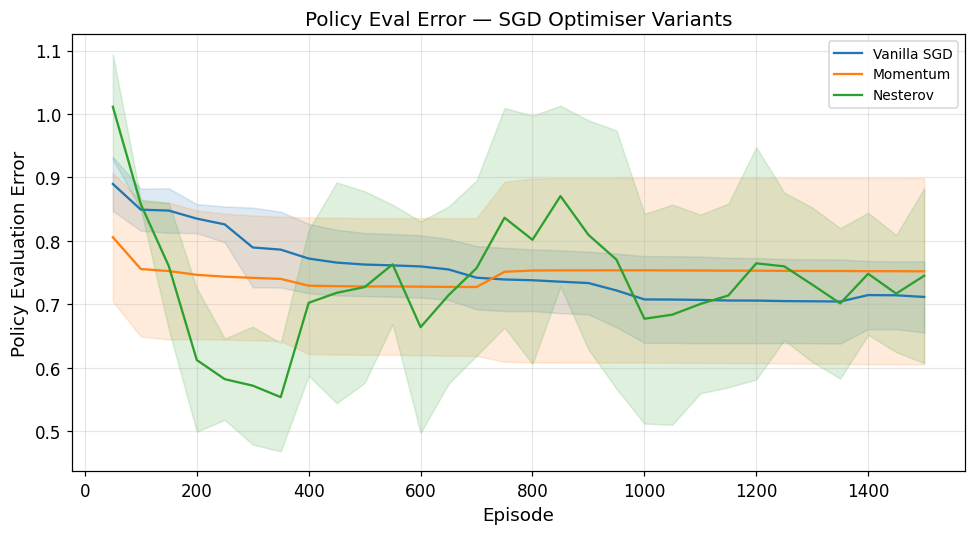

In [5]:
opt_results = {
    'Vanilla SGD':  sgd_results,
    'Momentum':     mom_results,
    'Nesterov':     nest_results,
}

fig = plot_multi_curves(
    opt_results, metric='policy_err',
    title='Policy Eval Error — SGD Optimiser Variants',
)
save_figure(fig, '06_optimiser_comparison')
plt.show()

## 4. Learning Rate Sensitivity

The step size is the critical hyperparameter for policy gradient methods.
Too large causes oscillation; too small causes slow convergence.

lr=0.001   final_policy_err=0.6851
lr=0.005   final_policy_err=0.6285
lr=0.01    final_policy_err=0.7119
lr=0.05    final_policy_err=0.7781
lr=0.1     final_policy_err=0.8673


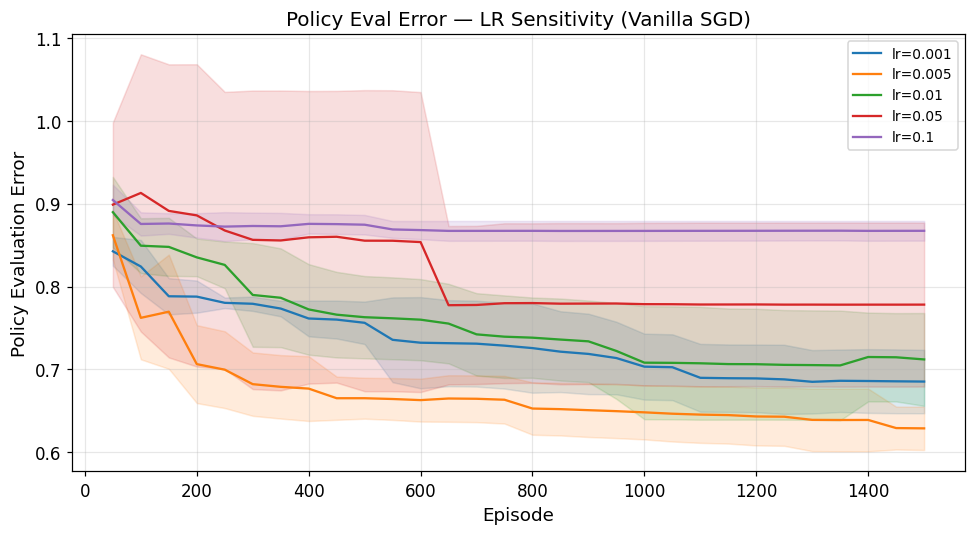

In [6]:
lr_values = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_results = {}

for lr_val in lr_values:
    res = multi_run(
        lambda rng, lr=lr_val: SGDPolicyAgent(rng, GAMMA, lr),
        n_runs=N_RUNS,
    )
    lr_results[f'lr={lr_val}'] = res
    print(f'lr={lr_val:<6}  final_policy_err={res["policy_err"][:, -1].mean():.4f}')

fig = plot_multi_curves(
    lr_results, metric='policy_err',
    title='Policy Eval Error — LR Sensitivity (Vanilla SGD)',
)
save_figure(fig, '06_lr_sensitivity')
plt.show()

## 5. Learned Policy

Final policy_err = 0.9739


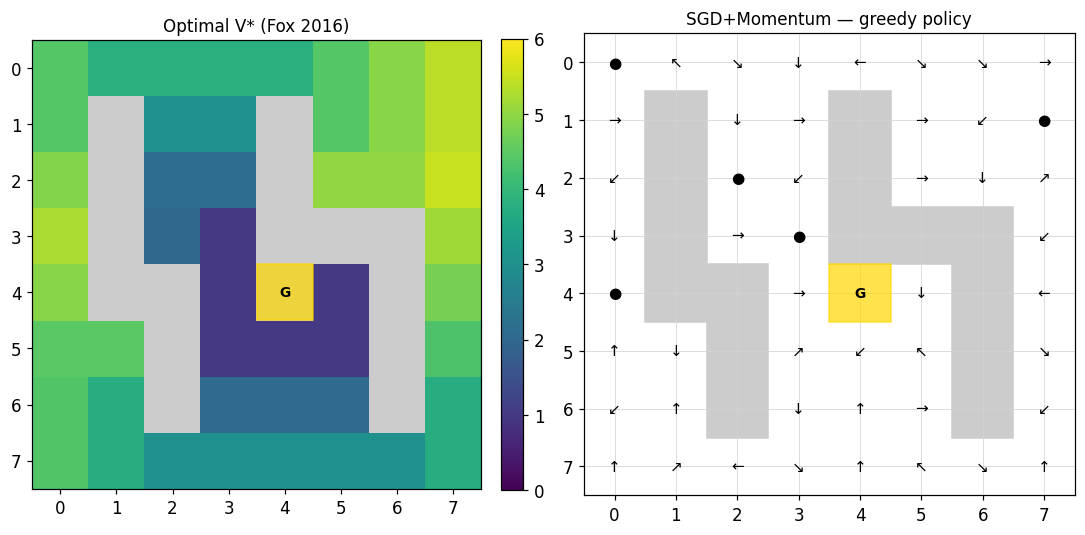

In [7]:
agent = SGDPolicyAgent(np.random.default_rng(42), GAMMA, LR, momentum=0.9)
env   = GridWorldEnv(np.random.default_rng(43))
for ep in range(N_EPS):
    run_one_episode(agent, env, MAX_ST)

pi = agent.get_policy()
print(f'Final policy_err = {policy_eval_error(pi):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_vstar_heatmap(ax=axes[0])
plot_policy_arrows(pi, title='SGD+Momentum — greedy policy', ax=axes[1])
fig.tight_layout()
save_figure(fig, '06_final_policy')
plt.show()

Vanilla SGD       policy_err=0.7119
Momentum          policy_err=0.7522
Nesterov          policy_err=0.7452


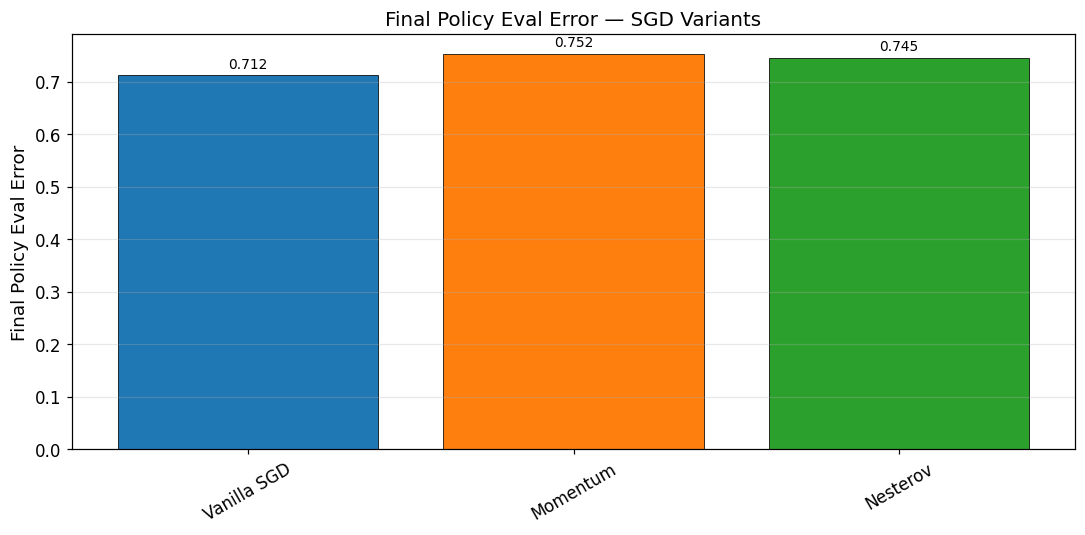

In [8]:
final_pol = {k: v['policy_err'][:, -1].mean() for k, v in opt_results.items()}
for k, v in final_pol.items():
    print(f'{k:<16}  policy_err={v:.4f}')
fig = plot_summary_bar(final_pol, title='Final Policy Eval Error — SGD Variants')
save_figure(fig, '06_summary_bar')
plt.show()

## Discussion

**Vanilla SGD** is identical to REINFORCE: each episode provides one gradient
estimate, and the parameter update is a fixed step in that direction. High
variance in G_t means the gradient direction changes dramatically episode-to-
episode, and convergence is erratic.

**Heavy-ball momentum** smooths the gradient direction by maintaining a velocity
that is an exponential moving average of past gradients. In directions where
the gradient is consistent the velocity builds up (larger effective step); in
oscillating directions the velocity cancels (smaller effective step). This can
help but also hurt if the gradient changes suddenly.

**Nesterov momentum** applies a one-step lookahead correction. For smooth
objectives it provably converges faster than heavy-ball momentum. With stochastic
gradients the advantage is less pronounced and problem-dependent.

The fundamental limitation shared by all three methods is that the gradient
signal comes from the *policy* gradient, not from a value-function approximation.
This makes them inherently high-variance. Actor-Critic methods (notebook 04)
address this by replacing G_t with a TD error, which has much lower variance.